# HSC and DESI Data Encoding with AION

This notebook demonstrates batched loading of HSC and DESI data, encoding using AION codecs, and visualizing embeddings with UMAP.

## Imports and Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from aion import AION
from aion.codecs import CodecManager
from aion.datasets import HSCDataset, DESIDataset

CACHE_DIR = "../data/"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


## Install and Import UMAP

In [2]:
from umap.umap_ import UMAP

## Load Datasets with Batching

In [3]:
BATCH_SIZE = 10
BATCH_COUNT = 2

print("Loading HSC dataset...")
hsc_dataset = HSCDataset(
    cache_dir=CACHE_DIR,
    batch_size=BATCH_SIZE,
    batch_count=BATCH_COUNT,
    device=device
)

print("\nLoading DESI dataset...")
desi_dataset = DESIDataset(
    cache_dir=CACHE_DIR,
    batch_size=BATCH_SIZE,
    batch_count=BATCH_COUNT,
    device=device
)

print(f"\nTotal HSC samples: {len(hsc_dataset)}")
print(f"Total DESI samples: {len(desi_dataset)}")

Loading HSC dataset...
Loaded 20 samples from disk: ../data/hsc_slice

Loading DESI dataset...
Loaded 20 samples from disk: ../data/desi_slice

Total HSC samples: 20
Total DESI samples: 20


## Initialize AION Model and Codec Manager

In [4]:
print("Loading AION model...")
model = AION.from_pretrained('polymathic-ai/aion-base').to(device)
print("Loading Codec Manager...")
codec_manager = CodecManager(device=device)
print("Model and codec manager loaded successfully")

Loading AION model...
Loading Codec Manager...
Model and codec manager loaded successfully


## Process HSC and DESI Together: Encode → Embed → Mean Average

In [5]:
print("Processing HSC and DESI batches together...")
all_embeddings_list = []

for i, (hsc_batch, desi_batch) in enumerate(zip(hsc_dataset, desi_dataset)):
    print(f"\nBatch {i+1}/{BATCH_COUNT}")
    print(f"  HSC: {hsc_batch.flux.shape}")
    print(f"  DESI: {desi_batch.flux.shape}")
    
    # Encode both modalities together
    tokens = codec_manager.encode(hsc_batch, desi_batch)
    print(f"    HSC tokens: {tokens['tok_image_hsc'].shape}")
    print(f"    DESI tokens: {tokens['tok_spectrum_desi'].shape}")
    
    # Generate embeddings from combined tokens
    embeddings = model.encode(tokens)
    print(f"    Combined embeddings shape: {embeddings.shape}")
    
    # Mean average over sequence length (dim=1)
    avg_embeddings = embeddings.mean(dim=1)
    print(f"    Averaged shape: {avg_embeddings.shape}")
    
    all_embeddings_list.append(avg_embeddings.cpu().detach())

# Concatenate all batches
all_embeddings = torch.cat(all_embeddings_list, dim=0).numpy()
print(f"\nFinal combined embeddings shape: {all_embeddings.shape}")
print(f"Total samples: {all_embeddings.shape[0]} (HSC+DESI pairs)")

Processing HSC and DESI batches together...

Batch 1/2
  HSC: torch.Size([10, 5, 160, 160])
  DESI: torch.Size([10, 7781])
    HSC tokens: torch.Size([10, 576])
    DESI tokens: torch.Size([10, 273])
    Combined embeddings shape: torch.Size([10, 256, 768])
    Averaged shape: torch.Size([10, 768])

Batch 2/2
  HSC: torch.Size([10, 5, 160, 160])
  DESI: torch.Size([10, 7781])
    HSC tokens: torch.Size([10, 576])
    DESI tokens: torch.Size([10, 273])
    Combined embeddings shape: torch.Size([10, 256, 768])
    Averaged shape: torch.Size([10, 768])

Final combined embeddings shape: (20, 768)
Total samples: 20 (HSC+DESI pairs)


## UMAP Visualization

Total embeddings shape: (20, 768)
Samples: 20 HSC+DESI pairs

Applying UMAP for 2D visualization...


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP reduced shape: (20, 2)


/tmp/ipykernel_11622/502913806.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


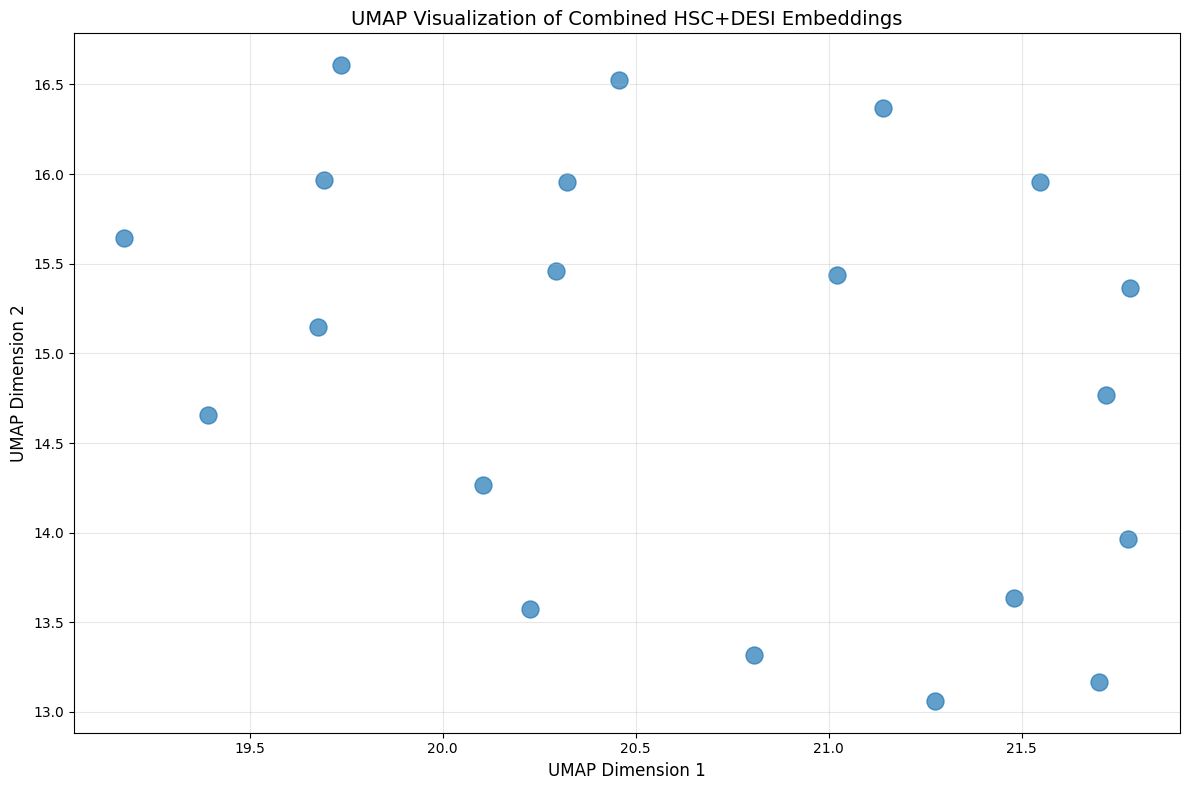


Original embedding dimension: 768
UMAP reduced dimension: 2


In [6]:
# all_embeddings already created in previous cell (combined HSC+DESI)

print(f"Total embeddings shape: {all_embeddings.shape}")
print(f"Samples: {all_embeddings.shape[0]} HSC+DESI pairs")

# Apply UMAP for 2D visualization
print("\nApplying UMAP for 2D visualization...")
reducer = UMAP(n_components=2, random_state=42, n_neighbors=5)
embeddings_2d = reducer.fit_transform(all_embeddings)

print(f"UMAP reduced shape: {embeddings_2d.shape}")

# Visualize
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    #c=range(len(embeddings_2d)),
    cmap='viridis',
    alpha=0.7,
    s=150
)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.title('UMAP Visualization of Combined HSC+DESI Embeddings', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOriginal embedding dimension: {all_embeddings.shape[1]}")
print(f"UMAP reduced dimension: {embeddings_2d.shape[1]}")

# DECODE




In [7]:
from aion.modalities import HSCImage, DESISpectrum, EuclidImage
reconstructed_image = codec_manager.decode(
    tokens,
    HSCImage,  # The modality from the 'tokens' dictionary we want to decode
    bands=hsc_batch.bands,
)  # Metadata required to reconstruct the given modality


In [9]:
for hsc_batch in hsc_dataset:
    pass

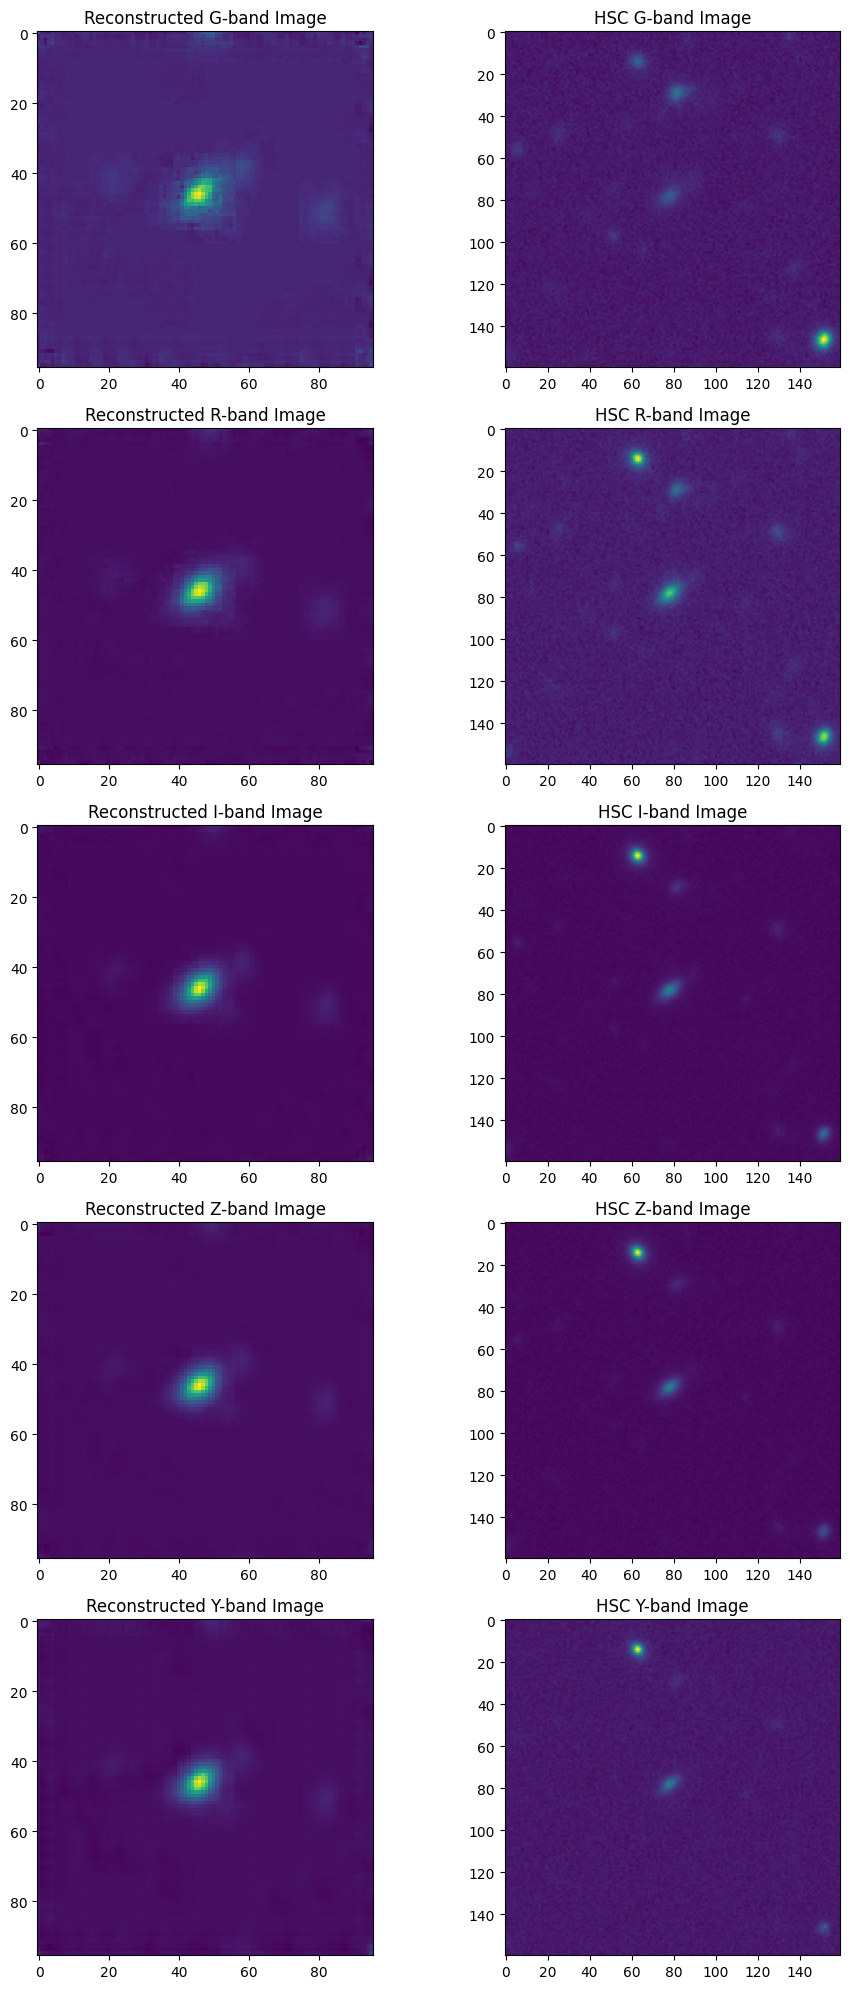

: 

In [ ]:
figure, axes = plt.subplots(5, 2, figsize=(10,20))
axes[0, 0].imshow(reconstructed_image.flux[0, 0].cpu().detach().numpy())
axes[0, 0].set_title("Reconstructed G-band Image")
axes[0, 1].imshow(hsc_batch.flux[0, 0].cpu().detach().numpy())
axes[0, 1].set_title("HSC G-band Image")
axes[1, 0].imshow(reconstructed_image.flux[0, 1].cpu().detach().numpy())
axes[1, 0].set_title("Reconstructed R-band Image")
axes[1, 1].imshow(hsc_batch.flux[0, 1].cpu().detach().numpy())
axes[1, 1].set_title("HSC R-band Image")
axes[2, 0].imshow(reconstructed_image.flux[0, 2].cpu().detach().numpy())
axes[2, 0].set_title("Reconstructed I-band Image")
axes[2, 1].imshow(hsc_batch.flux[0, 2].cpu().detach().numpy())
axes[2, 1].set_title("HSC I-band Image")
axes[3, 0].imshow(reconstructed_image.flux[0, 3].cpu().detach().numpy())
axes[3, 0].set_title("Reconstructed Z-band Image")
axes[3, 1].imshow(hsc_batch.flux[0, 3].cpu().detach().numpy())
axes[3, 1].set_title("HSC Z-band Image")
axes[4, 0].imshow(reconstructed_image.flux[0, 4].cpu().detach().numpy())
axes[4, 0].set_title("Reconstructed Y-band Image")
axes[4, 1].imshow(hsc_batch.flux[0, 4].cpu().detach().numpy())
axes[4, 1].set_title("HSC Y-band Image")
plt.tight_layout()
plt.show()